In [ ]:
import sys
print(sys.executable)

/Users/piyush/Code/ml/pong-pytorch/.venv/bin/python3


This notebook is supposed to be a demonstration of pong from pixels. 

The agent is not told what Pong is.. It is not given variables like: ball position = $(83, 42)$ , ball velocity = down-right  , my paddle position = $97$ . opponent paddle position = $51$  
It does not know hat some pixels constitute a ball, that another group constitutes your paddle  that objects persist from frame to frame, that the ball has a velocity, that it bounces. that your paddle can intercept it, that moving up now can cause a reward 20–50 frames later what a “good move” is.

Instead, at every instant it receives something much closer to what a camera would receive: a huge grid of pixel intensities. In his setup, the raw observation is a `210 × 160 × 3` image, or 100,800 numbers, and the agent has only two choices: move the paddle UP or DOWN. It gets `+1` when it scores, `-1` when it concedes, and usually `0` for hundreds of intervening actions. I gave you this repeatedly: [0, 0, 0, 144, 144, 0, 0, 0, ... 100,000 numbers ...] and told you only: Choose A or B. Then occasionally, much later: +1

That is amazing because there is an enormous conceptual gap between the input and the thing that must be learned.


In [14]:
#Import all the necessary libraries
import math # to do operations like sqrt
from pathlib import Path # to save checkpoint
import torch
import torch.nn as nn
import gymnasium as gym
import ale_py
import pong        # PROJECT_ROOT, and a checkpoint path of its own


[[[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [109 118  43]
  [109 118  43]
  [109 118  43]]

 [[109 118  43]
  [109 118  43]
  [109 118  43]
  ...
  [109 118  43]
  [109 118  43]
  [109 118  43]]

 [[109 118  43]
  [109 118  43]
  [109 118  43]
  ...
  [109 118  43]
  [109 118  43]
  [109 118  43]]

 ...

 [[ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]
  ...
  [ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]]

 [[ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]
  ...
  [ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]]

 [[ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]
  ...
  [ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]]]
{'lives': 0, 'episode_frame_number': 0, 'frame_number': 0}
Actions: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']
Action space: 4
<enum 'Action'>


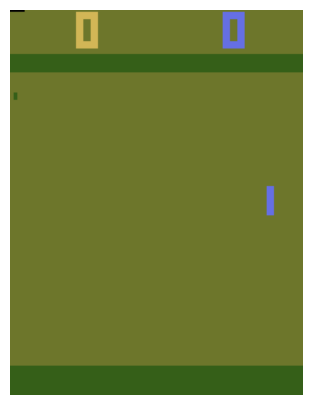

In [ ]:
# ------------------------------------------------------------
# Environment
# ------------------------------------------------------------

RENDER = False
gym.register_envs(ale_py)

env = gym.make(
    "ALE/Pong-v5",

    # These reproduce the important old Pong-v0 settings
    # that the original implementation relied on:
    frameskip=(4),
    repeat_action_probability=0,
    full_action_space=False,
    render_mode="human" if RENDER else "rgb_array",
)


In [27]:
# Test the environment is functioning
observation, info = env.reset()
print(observation)
print(info)
print("Actions:", env.unwrapped.get_action_meanings())
print("Action space:", env.action_space.sample())



[[[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [109 118  43]
  [109 118  43]
  [109 118  43]]

 [[109 118  43]
  [109 118  43]
  [109 118  43]
  ...
  [109 118  43]
  [109 118  43]
  [109 118  43]]

 [[109 118  43]
  [109 118  43]
  [109 118  43]
  ...
  [109 118  43]
  [109 118  43]
  [109 118  43]]

 ...

 [[ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]
  ...
  [ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]]

 [[ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]
  ...
  [ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]]

 [[ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]
  ...
  [ 53  95  24]
  [ 53  95  24]
  [ 53  95  24]]]
{'lives': 0, 'episode_frame_number': 0, 'frame_number': 0}
Actions: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']
Action space: 4


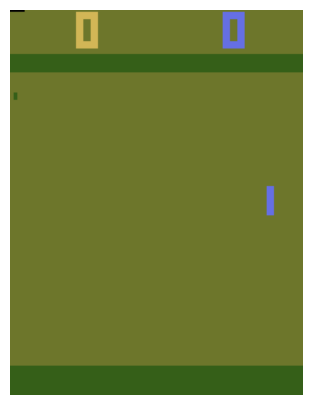

In [26]:

import matplotlib.pyplot as plt
from IPython.display import display, clear_output

obs, info = env.reset()

plt.figure(figsize=(4, 5))
plt.imshow(obs)
plt.axis("off")
plt.show()

In [ ]:

# ------------------------------------------------------------
# Preprocessing
# Reference NumPy version:
#
# def prepro(I):
#     I = I[35:195]
#     I = I[::2, ::2, 0]
#     I[I == 144] = 0
#     I[I == 109] = 0
#     I[I != 0] = 1
#     return I.astype(np.float).ravel()
# ------------------------------------------------------------

def preprocess(observation):
    """
    Convert a 210x160x3 Atari RGB frame into a
    6400-element PyTorch tensor.

    No NumPy code needed explicitly.
    """

    # Gym/ALE gives us a NumPy array.
    # Turn it into a torch tensor immediately.
    x = torch.from_numpy(observation)

    # 210x160x3
    #
    # Crop away top and bottom:
    # 160x160x3
    x = x[35:195]

    # Take every second pixel in both spatial dimensions,
    # and only one colour channel:
    #
    # 160x160x3 -> 80x80
    x = x[::2, ::2, 0]

    # Remove the two background colours,
    # then turn every remaining non-zero pixel into 1.
    #
    # Background -> 0
    # Ball/paddles -> 1
    x = (
        (x != 144)
        & (x != 109)
        & (x != 0)
    ).float()

    # 80x80 -> 6400
    x = x.flatten()

    return x.to(device)

In [ ]:
# Hyperparameters

learning_rate = 0.0001
batch_size = 32
gamma = 0.99 # discount rate
input_dim = 80 * 80
hidden_dim = 128
output_dim = env.action_space.n

In [ ]:
# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

# For this particular tiny, sequential network, I recommend CPU first.
# You can change this to "mps" later.
device = torch.device("cpu")

print(f"Using device: {device}")



In [ ]:
# ------------------------------------------------------------
# Hyperparameters
# ------------------------------------------------------------

H = 300
BATCH_SIZE = 10
LEARNING_RATE = 1e-4
GAMMA = 0.99
DECAY_RATE = 0.99

D = 80 * 80

RENDER = False
CHECKPOINT = pong.PROJECT_ROOT / "pong_exploration_policy.pt"

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

# For this particular tiny, sequential network, I recommend CPU first.
# You can change this to "mps" later.
device = torch.device("cpu")

print(f"Using device: {device}")

In [ ]:
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim=6400, hidden_dim=512):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim, bias=False)
        self.leaky_relu = nn.LeakyReLU()
        self.layer2 = nn.Linear(hidden_dim, 1, bias=False)
        self.sigmoid = nn.Sigmoid()
        # self.dropout = nn.Dropout(dropout)
    def forward(self, X):
        out = self.linear1(X)
        out = self.leaky_relu(out)
        out = self.linear2(out)
        out = self.sigmoid(out)
        return out

SyntaxError: incomplete input (3471545186.py, line 1)

In [ ]:
# ------------------------------------------------------------
# Policy network
#
# Reference NumPy version:
#
# h = np.dot(W1, x)
# h[h < 0] = 0
# logp = np.dot(W2, h)
# p = sigmoid(logp)
# ------------------------------------------------------------

class Policy(nn.Module):

    def __init__(self):
        super().__init__()

        # No biases: two bare weight matrices.
        self.fc1 = nn.Linear(
            D,
            H,
            bias=False,
        )

        self.fc2 = nn.Linear(
            H,
            1,
            bias=False,
        )

        # Match the reference initialization:
        #
        # W1 = randn(H, D) / sqrt(D)
        # W2 = randn(H)    / sqrt(H)

        nn.init.normal_(
            self.fc1.weight,
            mean=0.0,
            std=1.0 / math.sqrt(D),
        )

        nn.init.normal_(
            self.fc2.weight,
            mean=0.0,
            std=1.0 / math.sqrt(H),
        )

    def forward(self, x):

        h = self.fc1(x)

        h = torch.relu(h)

        logit = self.fc2(h)

        probability = torch.sigmoid(logit)

        return probability.squeeze()


policy = Policy().to(device)


In [ ]:

# ------------------------------------------------------------
# RMSProp
#
# This replaces the hand-written rmsprop_cache of the NumPy version.
# ------------------------------------------------------------

optimizer = torch.optim.RMSprop(
    policy.parameters(),
    lr=LEARNING_RATE,
    alpha=DECAY_RATE,
    eps=1e-5,
    momentum=0.0,
    weight_decay=0.0,
)



In [ ]:
# ------------------------------------------------------------
# Discount rewards
#
# This is almost literally the reference NumPy implementation.
# ------------------------------------------------------------

def discount_rewards(rewards):
    """
    rewards looks something like:

        [0, 0, 0, ..., -1, 0, 0, ..., +1, ...]

    Work backwards and assign discounted future reward
    to every action.
    """

    discounted = [0.0] * len(rewards)

    running_reward = 0.0

    for t in reversed(range(len(rewards))):

        # Pong-specific:
        #
        # +1 or -1 means one rally has finished.
        # Don't propagate reward across rally boundaries.
        if rewards[t] != 0:
            running_reward = 0.0

        running_reward = (
            running_reward * GAMMA
            + rewards[t]
        )

        discounted[t] = running_reward

    return torch.tensor(
        discounted,
        dtype=torch.float32,
        device=device,
    )

In [ ]:
# ------------------------------------------------------------
# Training state
# ------------------------------------------------------------

previous_frame = None

log_probs = []
rewards = []

episode_number = 0
reward_sum = 0.0
running_reward = None


# Important:
#
# PyTorch stores gradients in parameter.grad.
#
# We deliberately DON'T call optimizer.zero_grad()
# after every episode.
#
# That means gradients accumulate for BATCH_SIZE=10
# episodes, standing in for the NumPy version's grad_buffer.

optimizer.zero_grad()


# ------------------------------------------------------------
# Main RL loop
# ------------------------------------------------------------

try:

    while True:

        # ----------------------------------------------------
        # 1. Process current screen
        # ----------------------------------------------------

        current_frame = preprocess(observation)


        # ----------------------------------------------------
        # 2. Compute difference image
        #
        # Reference NumPy version:
        #
        # x = cur_x - prev_x
        # ----------------------------------------------------

        if previous_frame is None:
            x = torch.zeros(
                D,
                dtype=torch.float32,
                device=device,
            )
        else:
            x = current_frame - previous_frame

        previous_frame = current_frame


        # ----------------------------------------------------
        # 3. Run policy network
        #
        # probability means:
        #
        #       P(action 2 | current state)
        # ----------------------------------------------------

        probability = policy(x)


        # ----------------------------------------------------
        # 4. Construct Bernoulli distribution
        #
        # Example:
        #
        # probability = 0.7
        #
        # sampled_action = 1 with probability 0.7
        # sampled_action = 0 with probability 0.3
        # ----------------------------------------------------

        distribution = torch.distributions.Bernoulli(
            probs=probability
        )


        # ----------------------------------------------------
        # 5. Sample from policy
        # ----------------------------------------------------

        sampled_action = distribution.sample()


        # ----------------------------------------------------
        # 6. Remember log probability of WHAT WE ACTUALLY DID
        #
        # If sampled_action == 1:
        #
        #     log_prob = log(p)
        #
        # If sampled_action == 0:
        #
        #     log_prob = log(1-p)
        #
        # This replaces the NumPy version's:
        #
        #     y - aprob
        # ----------------------------------------------------

        log_prob = distribution.log_prob(sampled_action)

        log_probs.append(log_prob)


        # ----------------------------------------------------
        # 7. Convert Bernoulli result into Atari action
        #
        # This follows the reference implementation:
        #
        # action 2 if sample == 1
        # action 3 if sample == 0
        # ----------------------------------------------------

        if sampled_action.item() == 1:
            action = 2
        else:
            action = 3


        # ----------------------------------------------------
        # 8. Act in the environment
        # ----------------------------------------------------

        observation, reward, terminated, truncated, info = (
            env.step(action)
        )

        done = terminated or truncated

        reward_sum += reward
        rewards.append(float(reward))


        # ----------------------------------------------------
        # Print when a Pong point ends
        # ----------------------------------------------------

        if reward != 0:

            marker = " !!!!!!!!" if reward == 1 else ""

            print(
                f"episode {episode_number}: "
                f"point finished, "
                f"reward {reward:+.0f}"
                f"{marker}"
            )


        # ----------------------------------------------------
        # 9. If the whole Pong episode finished...
        # ----------------------------------------------------

        if done:

            episode_number += 1


            # ------------------------------------------------
            # 10. Calculate discounted return R_t
            # ------------------------------------------------

            returns = discount_rewards(rewards)


            # ------------------------------------------------
            # 11. Normalize returns
            #
            # Reference NumPy version:
            #
            # discounted_epr -= mean
            # discounted_epr /= std
            #
            # This behaves like a crude advantage estimate.
            # ------------------------------------------------

            returns = (
                returns - returns.mean()
            ) / (
                returns.std(unbiased=False) + 1e-8
            )


            # ------------------------------------------------
            # 12. Stack log probabilities
            # ------------------------------------------------

            episode_log_probs = torch.stack(log_probs)


            # ------------------------------------------------
            # 13. REINFORCE objective
            #
            # The NumPy version effectively calculates:
            #
            #       return * ∇ log π(a|s)
            #
            # In PyTorch we write the scalar objective:
            #
            #       loss =
            #       - Σ return_t log π(a_t | s_t)
            #
            # and let autograd differentiate it.
            # ------------------------------------------------

            loss = -(
                episode_log_probs * returns
            ).sum()


            # ------------------------------------------------
            # 14. Backpropagation
            #
            # THIS replaces policy_backward().
            # ------------------------------------------------

            loss.backward()


            # ------------------------------------------------
            # 15. Every 10 episodes update the network
            #
            # Since we did not zero gradients above,
            # .grad contains the sum of gradients from
            # all 10 episodes.
            #
            # This replaces the NumPy version's grad_buffer.
            # ------------------------------------------------

            if episode_number % BATCH_SIZE == 0:

                optimizer.step()

                optimizer.zero_grad()

                print(
                    f"\n*** parameter update "
                    f"after episode {episode_number} ***\n"
                )


            # ------------------------------------------------
            # 16. Running reward
            # ------------------------------------------------

            if running_reward is None:
                running_reward = reward_sum
            else:
                running_reward = (
                    running_reward * 0.99
                    + reward_sum * 0.01
                )

            print(
                f"episode {episode_number} finished | "
                f"reward: {reward_sum:.1f} | "
                f"running mean: {running_reward:.3f} | "
                f"loss: {loss.item():.3f}"
            )


            # ------------------------------------------------
            # 17. Save occasionally
            # ------------------------------------------------

            if episode_number % 100 == 0:

                torch.save(
                    {
                        "episode": episode_number,
                        "model_state_dict":
                            policy.state_dict(),

                        "optimizer_state_dict":
                            optimizer.state_dict(),

                        "running_reward":
                            running_reward,
                    },
                    CHECKPOINT,
                )

                print(
                    f"Saved checkpoint to {CHECKPOINT}"
                )


            # ------------------------------------------------
            # 18. Reset episode memory
            # ------------------------------------------------

            reward_sum = 0.0

            log_probs = []
            rewards = []

            observation, info = env.reset()

            previous_frame = None


finally:
    env.close()

In [7]:
 # Calculate Loss and Grads
action_probs = model(inputs)
log_prob_actions = nn.BCELoss(reduction='none')(action_probs.squeeze(-1), targets) / batch_size  # batch_size == grad accumulation iterations
loss = log_prob_actions * stepwise_returns
loss = loss.sum()  # not average, since each episode is used as a one data sample
weighted_loss.backward()

NameError: name 'model' is not defined

After preprocessing, one Pong state is a vector $x∈R^{6400}$

Policy gradients give an almost comically crude answer:

Try things. If the eventual outcome was unusually good, make the actions you took slightly more probable. If it was bad, make them slightly less probable. Across enormous numbers of trials, the statistical signal accumulates.

The important pattern is: raw sensory data→actions→eventual reward $\boxed{\text{raw sensory data} \rightarrow \text{actions} \rightarrow \text{eventual reward}}$ rather than: human-designed representation→human-written rules→action.


Robotics: detect cup, estimate cup, pose estimate, hand pose calculate, grasp point, calculate trajectory

Instead: camera pixels -> proprioception -> maybe tactile signals ↓ neural network -> motor commands -> did the cup get picked up?

In [ ]:
policy = Policy()
optimizer = torch.optim.RMSprop(policy.parameters(), lr=1e-4)

obs, info = env.reset()
previous_frame = None

while True:

    # 1. image -> 6400 torch values
    current_frame = preprocess(obs)

    # 2. encode movement
    x = current_frame - previous_frame
    previous_frame = current_frame

    # 3. policy
    p = policy(x)

    # 4. stochastic action
    dist = Bernoulli(p)
    sampled_action = dist.sample()

    # 5. remember probability of what we actually did
    log_probs.append(dist.log_prob(sampled_action))

    # 6. do it in Pong
    obs, reward, terminated, truncated, info = env.step(...)

    rewards.append(reward)

    if terminated or truncated:

        # 7. future rewards for each past decision
        returns = discount_rewards(rewards)

        # 8. REINFORCE objective
        loss = -(log_probs * returns).sum()

        # 9. PyTorch calculates W1/W2 gradients
        loss.backward()

        # eventually:
        optimizer.step()

**Question: How any weights does the network have?**

Compare to gpu:
device = torch.device("mps")